<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Box Plots**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize data composition and comparisons using box plots.


### Setup: Connecting to the Database


#### 1. Download the Database File


In [2]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

--2026-05-09 09:21:22--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-results-public.sqlite.1’

survey-results-publ 100%[===================>] 201.62M  37.6MB/s    in 5.2s    

2026-05-09 09:21:31 (38.6 MB/s) - ‘survey-results-public.sqlite.1’ saved [211415040/211415040]



#### 2. Connect to the Database


**Install the needed libraries**


In [3]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 180.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 177.1 MB/s eta 0:00:00


In [4]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 144.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 151.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 95.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 160.8 MB/s eta 0:00:00


In [5]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to the SQLite database
conn = sqlite3.connect('survey-results-public.sqlite')


## Demo: Basic SQL Queries


#### Demo 1: Count the Number of Rows in the Table


In [6]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437


#### Demo 2: List All Tables


In [7]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


#### Demo 3: Group Data by Age


In [8]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Visualizing Data


### Task 1: Visualizing the Distribution of Data


**1. Box Plot of `CompTotal` (Total Compensation)**


Use a box plot to analyze the distribution and outliers in total compensation.


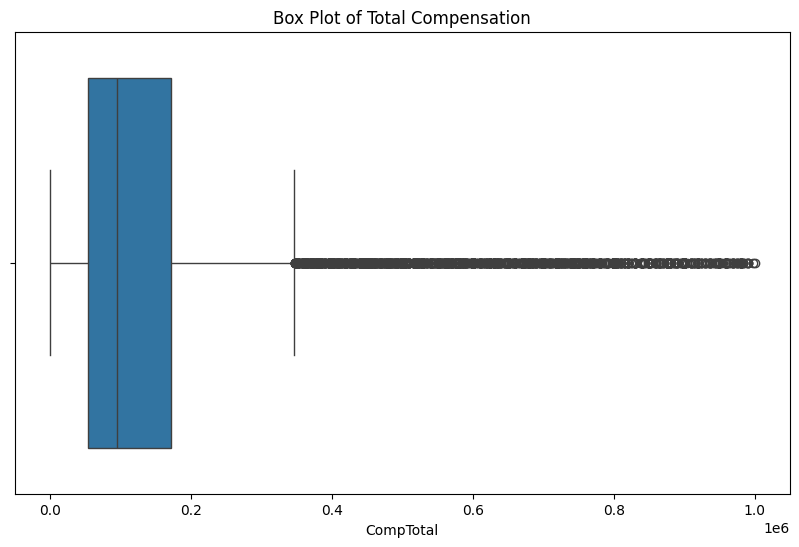

In [9]:
# your code goes here
# SQL query
!pip install seaborn
import seaborn as sns

QUERY = """
SELECT CompTotal
FROM main
WHERE CompTotal IS NOT NULL
"""


# Read query

df_comp = pd.read_sql_query(QUERY, conn)


# Convert to numeric

df_comp['CompTotal'] = pd.to_numeric(
    df_comp['CompTotal'],
    errors='coerce'
)


# Remove missing values

df_comp = df_comp.dropna()


# Remove extreme outliers

df_comp = df_comp[
    df_comp['CompTotal'] < 1000000
]


# Create box plot

plt.figure(figsize=(10,6))

sns.boxplot(
    x=df_comp['CompTotal']
)


# Add title

plt.title(
    "Box Plot of Total Compensation"
)


# Show graph

plt.show()

**2. Box Plot of Age (converted to numeric values)**


Convert the `Age` column into numerical values and visualize the distribution.


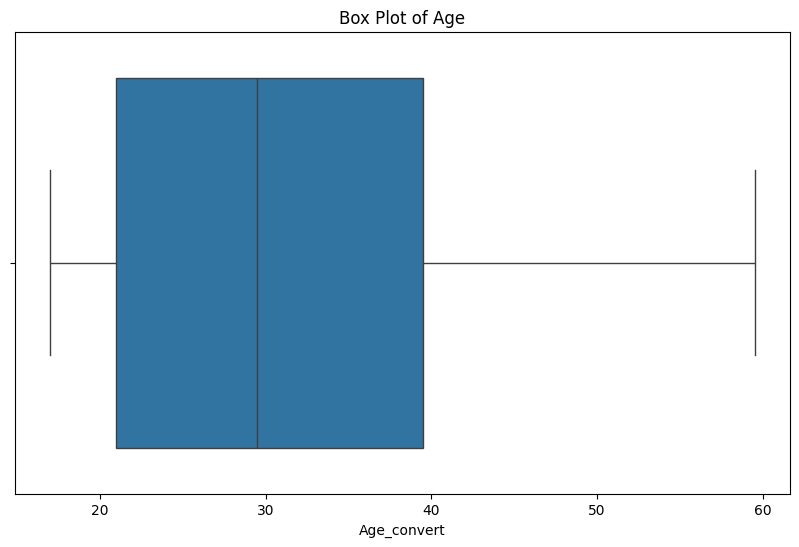

In [10]:
# your code goes here
def convert_age(age):

    if pd.isna(age):
        return None

    age = str(age).lower().replace(
        "years old", ""
    ).strip()


    # Under 18

    if "under" in age:
        return 17


    # Age ranges

    elif "-" in age:

        parts = age.split("-")

        return (
            int(parts[0]) + int(parts[1])
        ) / 2


    # Single number

    elif age.isdigit():
        return int(age)


    return None

# SQL query

QUERY = """
SELECT Age
FROM main
WHERE Age IS NOT NULL
"""


# Read query

df_age = pd.read_sql_query(QUERY, conn)


# Convert Age

df_age['Age_convert'] = df_age[
    'Age'
].apply(convert_age)


# Remove missing values

df_age = df_age.dropna()


# Create box plot

plt.figure(figsize=(10,6))

sns.boxplot(
    x=df_age['Age_convert']
)


# Add title

plt.title(
    "Box Plot of Age"
)


# Show graph

plt.show()

### Task 2: Visualizing Relationships in Data


**1. Box Plot of `CompTotal` Grouped by Age Groups:**


Visualize the distribution of compensation across different age groups.


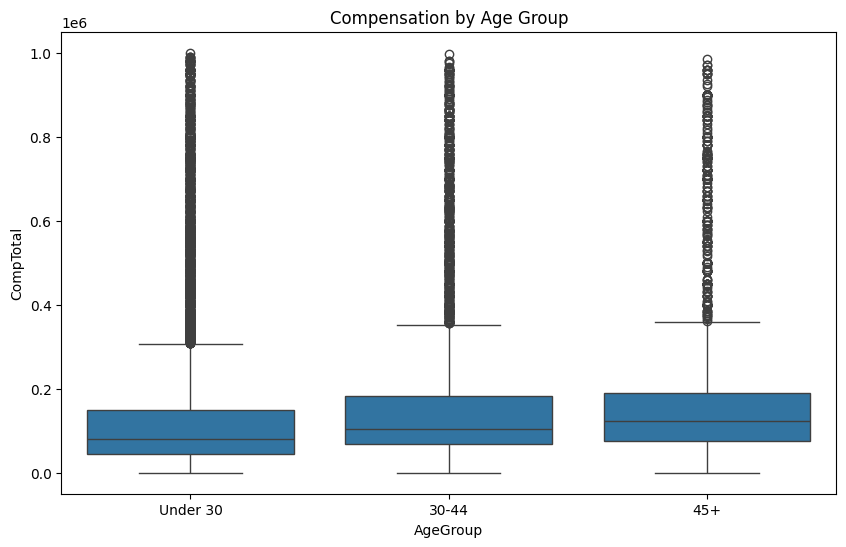

In [11]:
# your code goes here
# SQL query

QUERY = """
SELECT Age, CompTotal
FROM main
WHERE CompTotal IS NOT NULL
"""


# Read query

df_group = pd.read_sql_query(QUERY, conn)


# Convert columns

df_group['Age_convert'] = df_group[
    'Age'
].apply(convert_age)

df_group['CompTotal'] = pd.to_numeric(
    df_group['CompTotal'],
    errors='coerce'
)


# Remove missing values

df_group = df_group.dropna()


# Remove huge outliers

df_group = df_group[
    df_group['CompTotal'] < 1000000
]


# Create Age Groups

def age_group(age):

    if age < 30:
        return 'Under 30'

    elif age < 45:
        return '30-44'

    else:
        return '45+'


df_group['AgeGroup'] = df_group[
    'Age_convert'
].apply(age_group)


# Create box plot

plt.figure(figsize=(10,6))

sns.boxplot(
    x='AgeGroup',
    y='CompTotal',
    data=df_group
)


# Add title

plt.title(
    "Compensation by Age Group"
)


# Show graph

plt.show()

**2. Box Plot of `CompTotal` Grouped by Job Satisfaction (`JobSatPoints_6`):**


Examine how compensation varies based on job satisfaction levels.


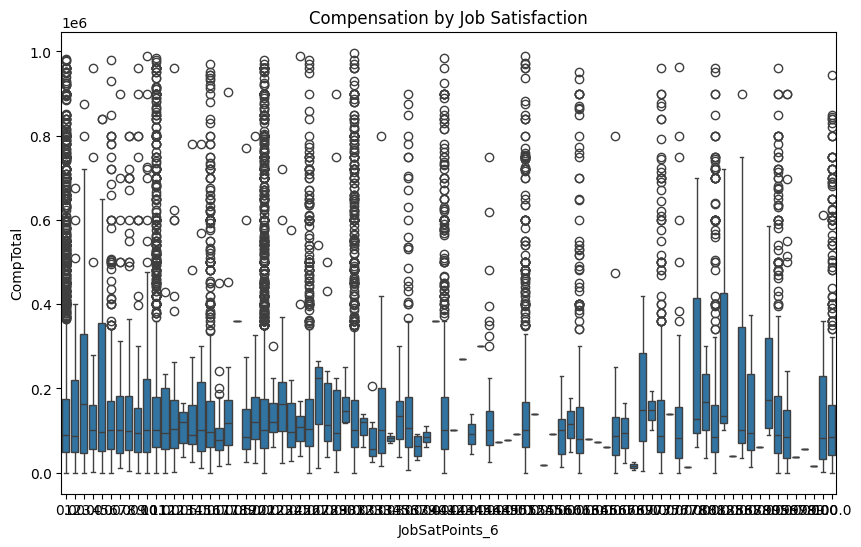

In [12]:
# your code goes here
# SQL query

QUERY = """
SELECT CompTotal, JobSatPoints_6
FROM main
WHERE CompTotal IS NOT NULL
AND JobSatPoints_6 IS NOT NULL
"""


# Read query

df_job = pd.read_sql_query(QUERY, conn)


# Convert columns

df_job['CompTotal'] = pd.to_numeric(
    df_job['CompTotal'],
    errors='coerce'
)

df_job['JobSatPoints_6'] = pd.to_numeric(
    df_job['JobSatPoints_6'],
    errors='coerce'
)


# Remove missing values

df_job = df_job.dropna()


# Remove outliers

df_job = df_job[
    df_job['CompTotal'] < 1000000
]


# Create box plot

plt.figure(figsize=(10,6))

sns.boxplot(
    x='JobSatPoints_6',
    y='CompTotal',
    data=df_job
)


# Add title

plt.title(
    "Compensation by Job Satisfaction"
)


# Show graph

plt.show()

### Task 3: Visualizing the Composition of Data


**1. Box Plot of `ConvertedCompYearly` for the Top 5 Developer Types:**


Analyze compensation across the top 5 developer roles.


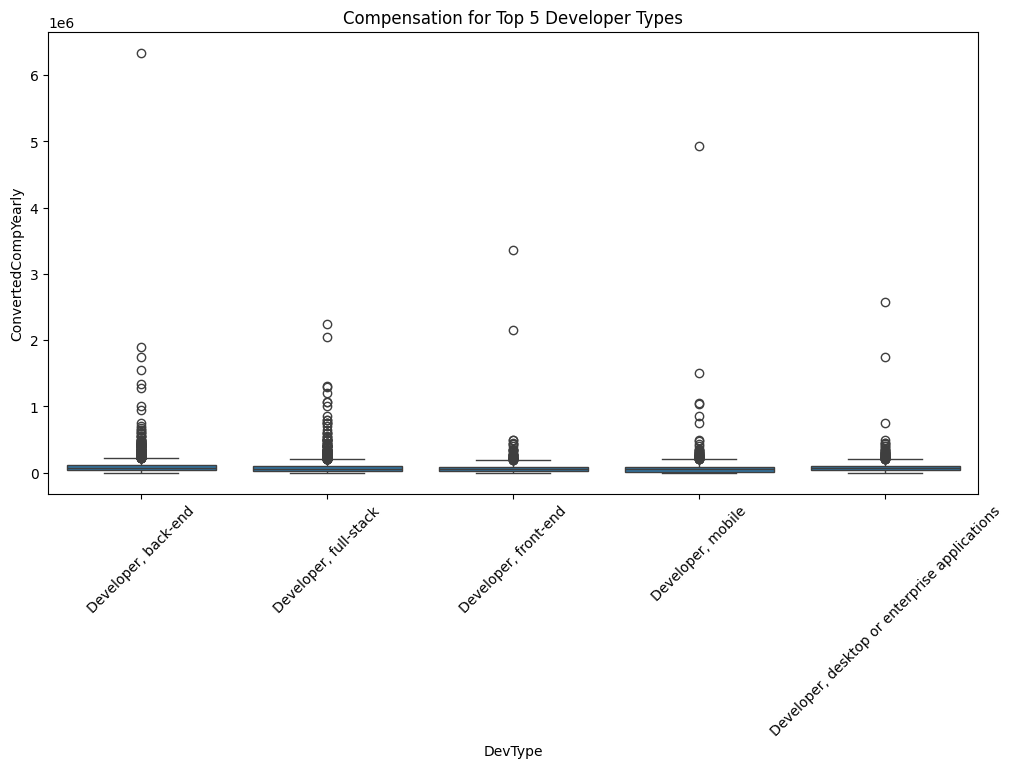

In [13]:
# your code goes here
# SQL query

QUERY = """
SELECT DevType, ConvertedCompYearly
FROM main
WHERE DevType IS NOT NULL
AND ConvertedCompYearly IS NOT NULL
"""


# Read query

df_dev = pd.read_sql_query(QUERY, conn)


# Get top 5 developer types

top5 = df_dev['DevType'].value_counts().head(5).index


# Filter top 5

df_dev = df_dev[
    df_dev['DevType'].isin(top5)
]


# Create box plot

plt.figure(figsize=(12,6))

sns.boxplot(
    x='DevType',
    y='ConvertedCompYearly',
    data=df_dev
)


# Rotate labels

plt.xticks(rotation=45)


# Add title

plt.title(
    "Compensation for Top 5 Developer Types"
)


# Show graph

plt.show()

**2. Box Plot of `CompTotal` for the Top 5 Countries:**


Analyze compensation across respondents from the top 5 countries.


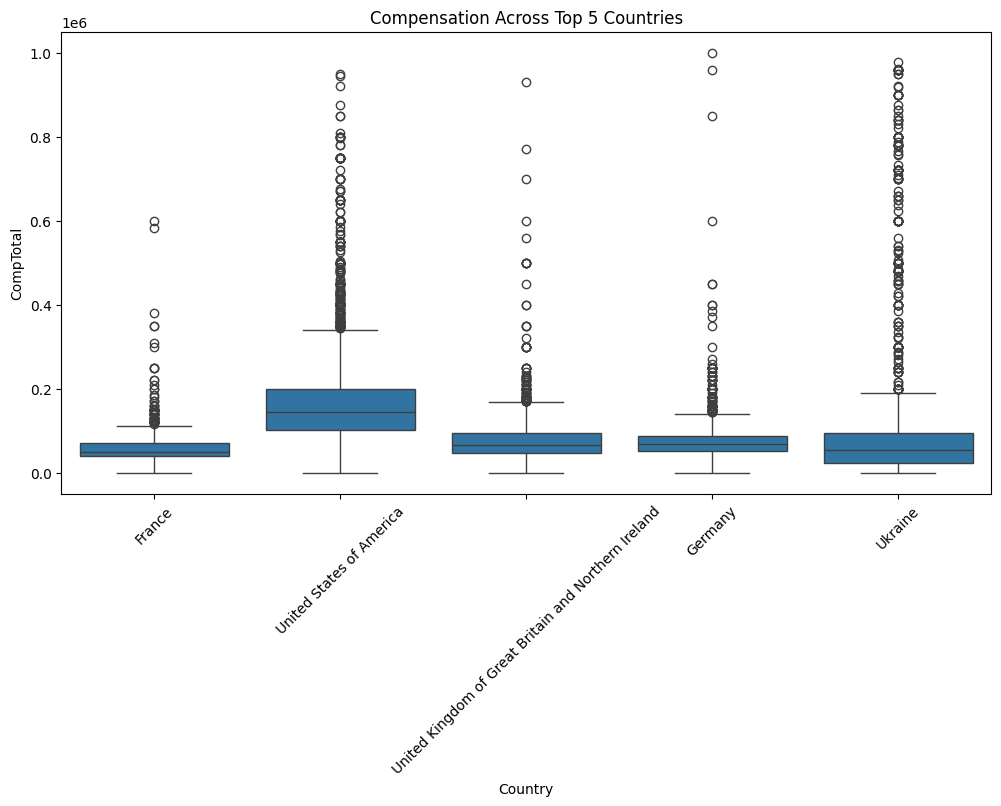

In [14]:
# your code goes here
# SQL query

QUERY = """
SELECT Country, CompTotal
FROM main
WHERE Country IS NOT NULL
AND CompTotal IS NOT NULL
"""


# Read query

df_country = pd.read_sql_query(QUERY, conn)


# Convert compensation

df_country['CompTotal'] = pd.to_numeric(
    df_country['CompTotal'],
    errors='coerce'
)


# Remove missing values

df_country = df_country.dropna()


# Remove outliers

df_country = df_country[
    df_country['CompTotal'] < 1000000
]


# Find top 5 countries

top5 = df_country[
    'Country'
].value_counts().head(5).index


# Filter top 5

df_country = df_country[
    df_country['Country'].isin(top5)
]


# Create box plot

plt.figure(figsize=(12,6))

sns.boxplot(
    x='Country',
    y='CompTotal',
    data=df_country
)


# Rotate labels

plt.xticks(rotation=45)


# Add title

plt.title(
    "Compensation Across Top 5 Countries"
)


# Show graph

plt.show()

### Task 4: Visualizing Comparison of Data


**1. Box Plot of CompTotal Across Employment Types:**


Analyze compensation for different employment types.


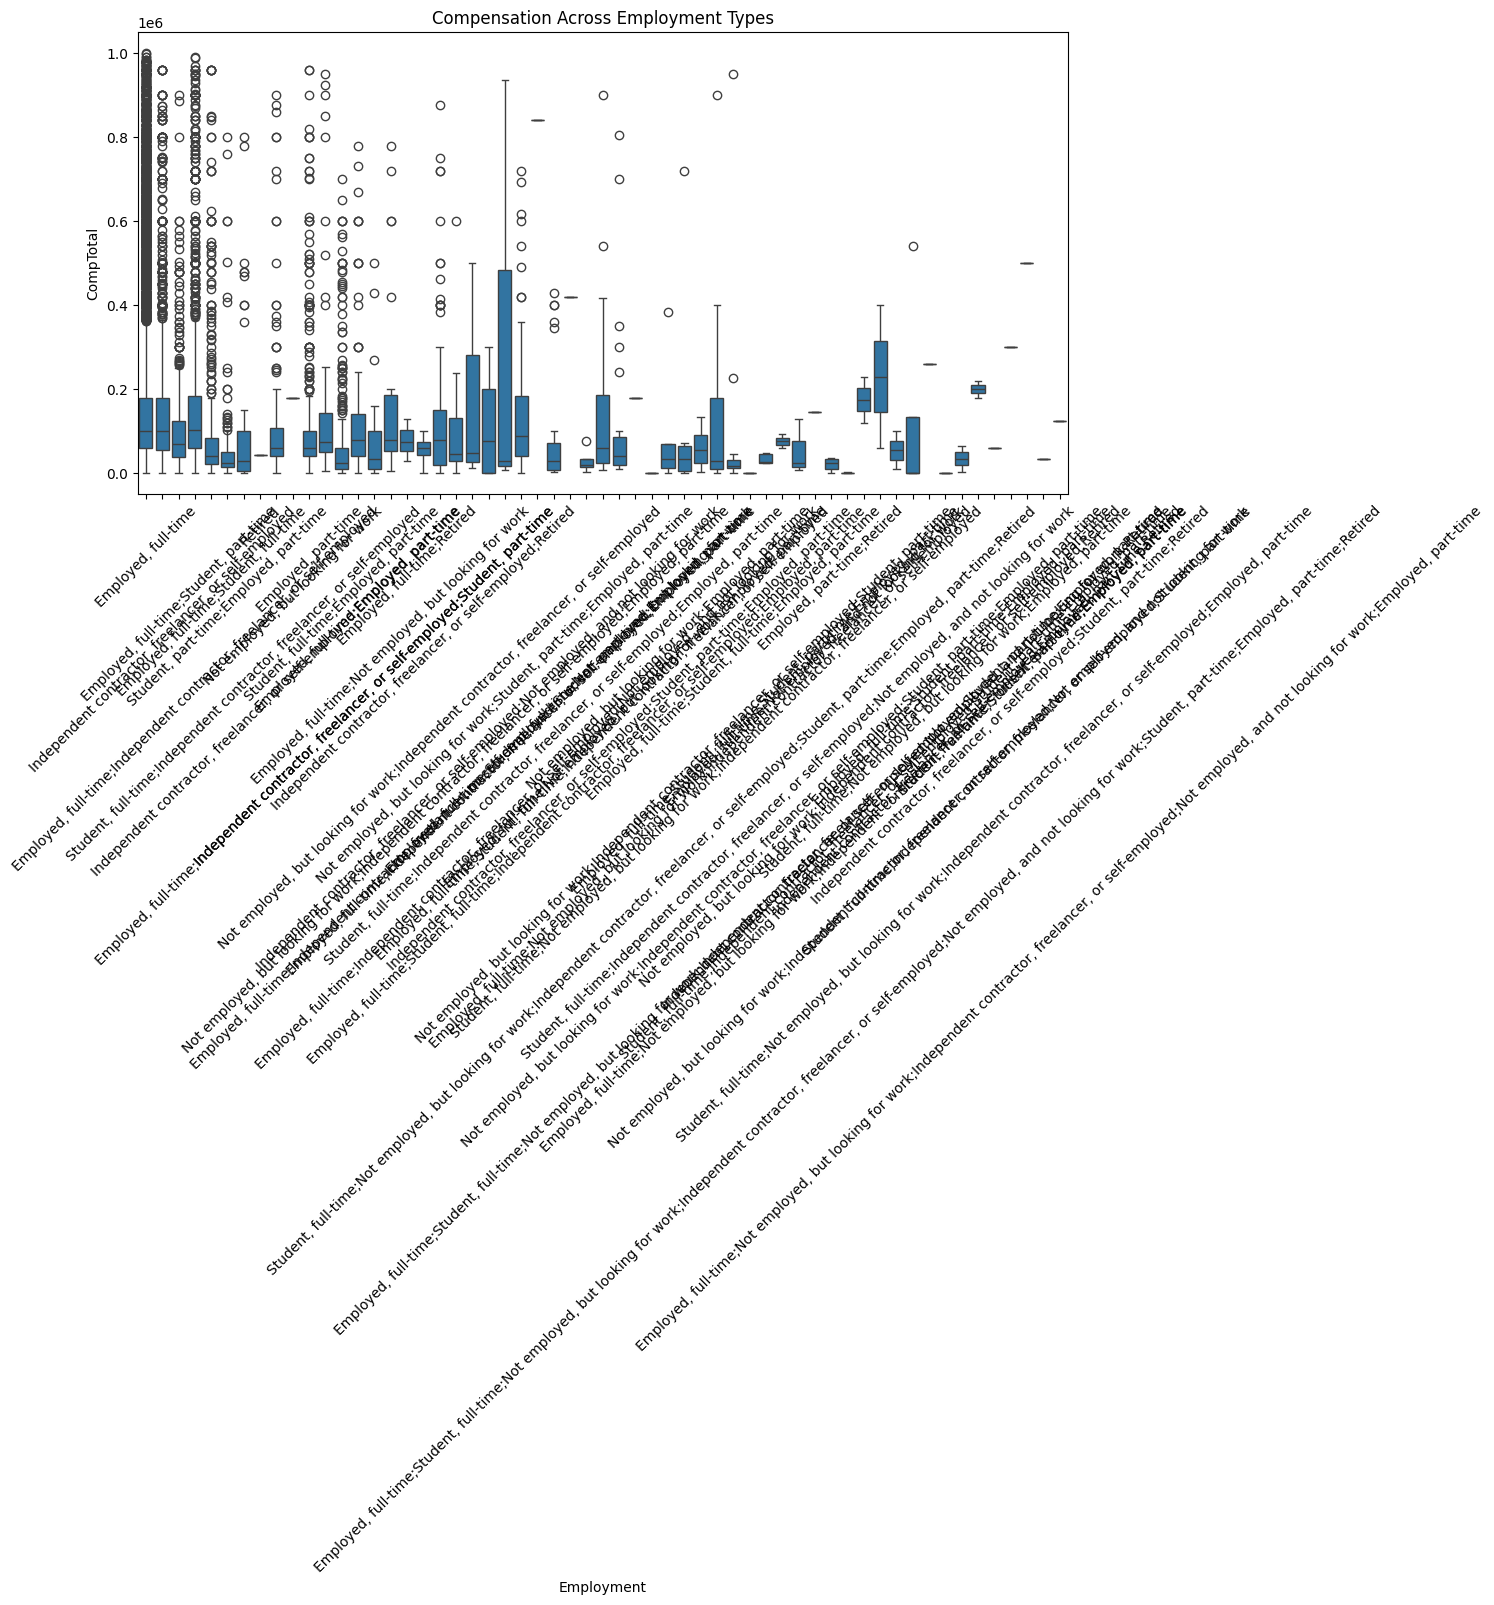

In [15]:
# your code goes here
# SQL query

QUERY = """
SELECT Employment, CompTotal
FROM main
WHERE Employment IS NOT NULL
AND CompTotal IS NOT NULL
"""


# Read query

df_emp = pd.read_sql_query(QUERY, conn)


# Convert compensation

df_emp['CompTotal'] = pd.to_numeric(
    df_emp['CompTotal'],
    errors='coerce'
)


# Remove missing values

df_emp = df_emp.dropna()


# Remove outliers

df_emp = df_emp[
    df_emp['CompTotal'] < 1000000
]


# Create box plot

plt.figure(figsize=(12,6))

sns.boxplot(
    x='Employment',
    y='CompTotal',
    data=df_emp
)


# Rotate labels

plt.xticks(rotation=45)


# Add title

plt.title(
    "Compensation Across Employment Types"
)


# Show graph

plt.show()

**2. Box Plot of `YearsCodePro` by Job Satisfaction (`JobSatPoints_6`):**


Examine the distribution of professional coding years by job satisfaction levels.


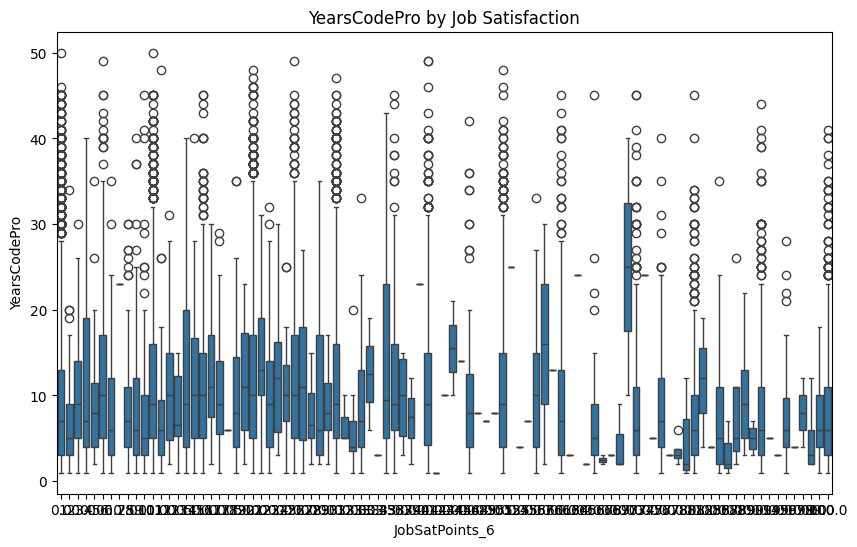

In [16]:
# your code goes here
# SQL query

QUERY = """
SELECT YearsCodePro, JobSatPoints_6
FROM main
WHERE YearsCodePro IS NOT NULL
AND JobSatPoints_6 IS NOT NULL
"""


# Read query

df_years = pd.read_sql_query(QUERY, conn)


# Convert columns

df_years['YearsCodePro'] = pd.to_numeric(
    df_years['YearsCodePro'],
    errors='coerce'
)

df_years['JobSatPoints_6'] = pd.to_numeric(
    df_years['JobSatPoints_6'],
    errors='coerce'
)


# Remove missing values

df_years = df_years.dropna()


# Create box plot

plt.figure(figsize=(10,6))

sns.boxplot(
    x='JobSatPoints_6',
    y='YearsCodePro',
    data=df_years
)


# Add title

plt.title(
    "YearsCodePro by Job Satisfaction"
)


# Show graph

plt.show()

### Final Step: Close the Database Connection


After completing the lab, close the connection to the SQLite database:


In [17]:
conn.close()

## Summary


In this lab, you used box plots to visualize various aspects of the dataset, focusing on:

- Visualize distributions of compensation and age.

- Explore relationships between compensation, job satisfaction, and professional coding experience.

- Analyze data composition across developer roles and countries.

- Compare compensation across employment types and satisfaction levels.

Box plots provided clear insights into the spread, outliers, and central tendencies of various features in the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
